<!-- # The FITS pixel table  -->

I need GSFC support for count response functions, with the following requirements

Given:
* a dataset, defined by FT1/FT2 with GTI (as for a catalog):
* A set of _bands_, each defined by an energy range, event type, zmax value, and HEALPix nside
* A set of diffuse models and a catalog with point and extended sources

Code that will generate:

* The number of data photons in each pixel, and
* For each model a table with the predicted number of photons for each pixel with at least one data photon
    * For diffuse models, also a table with the total counts for each band. (Accounts for the empty pixels, providing the normalization needed for the diffuse optimization.)

    * For the source spectral optimization, an optional requirement is to support gradients. For the given subset of the source parameters to optimize, propagate the matrix of partial derivatives of the counts with respect to the parameters. The likelihood calculation needs to propagate these to the derivatives of the likelihood. This speeds up the optimization.


In [1]:
%reset -f
%run pylib/tools dark date
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *

<h5 style="text-align:right; margin-right:15px"> 2026-03-17 05:58</h5>

In [2]:
KerrDataFile.to_fits('files/kerr/toby_v3', 'files/kerr/toby_v3.fits', overwrite=True)

Loaded Kerr model from "files/kerr/toby_v3.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            
wrote file files/kerr/toby_v3.fits


In [3]:
from astropy.io import fits
with fits.open('files/kerr/toby_v3.fits') as hdul:
    hdul.info()
    skymap = hdul[1].data
    print(skymap.dtype)

Filename: files/kerr/toby_v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SKYMAP        1 BinTableHDU     21   8241643R x 3C   [J, I, J]   
  2  BANDS         1 BinTableHDU     20   43R x 4C   [J, D, D, J]   
(numpy.record, [('PIX', '>i4'), ('CHANNEL', '>i2'), ('VALUE', '>i4')])


In [ ]:
pt = PixelTable('files/kerr/toby_v3')

Loaded Kerr model from "files/kerr/toby_v3.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons
            8,241,643 pixels
            


In [5]:
photons = pt.photons
global_models = (pt.diffuse+pt.sunmoon)[:len(pt.photons)]
local_models = pt.ptsrc[:len(pt.photons)]
show(f""" Model Totals: {global_models.sum():,.0f} global, {local_models.sum():,.0f} local
<br> Photons: {pt.photons.sum():,.0f}
<br>Global/local ratio: {global_models.sum()/local_models.sum():.2f}""")

Model Totals: 170,562,406 global, 29,229,134 local
<br> Photons: 206,555,017
<br>Global/local ratio: 5.84

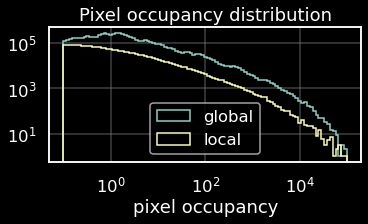

In [ ]:
plt.hist(global_models, bins=np.logspace(-1, 5, 100), histtype='step', label='diffuse')
plt.hist(local_models, bins=np.logspace(-1, 5, 100), histtype='step', label='local')
plt.gca().set(xscale='log', yscale='log', xlabel = 'pixel occupancy',
title='Pixel occupancy distribution')
plt.legend();

In [7]:
sum([sum(band.diffuse) for band in pt.values()])

170178508.0232192

In [8]:
len(global_models), len(local_models), len(pt.photons)

(8241643, 8241643, 8241643)